In [17]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [18]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class_comparison"
less_bias_strength = "0.1"
method = "fw-mrs-temperature"
data_set_name = "folktables_income"

In [19]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [20]:
aurocs

,0.5,0.1,0.05,0.01,0.005,0.001,0.0,-0.001,-0.005,-0.05,-0.01,-0.1,-0.5
0,0.834274,0.826642,0.822395,0.793644,0.778616,0.724861,0.836655,0.816780,0.826036,0.839405,0.827967,0.838832,0.831158
1,0.838508,0.841414,0.841835,0.813500,0.787753,0.720768,0.842974,0.806832,0.808678,0.836868,0.819726,0.840099,0.836644
2,0.829052,0.824808,0.826269,0.795582,0.769140,0.713305,0.826223,0.809206,0.820080,0.828364,0.824810,0.832338,0.827382
3,0.839135,0.837241,0.837591,0.806126,0.786050,0.740760,0.843921,0.813535,0.817936,0.838616,0.833863,0.843203,0.838228
4,0.831283,0.833907,0.827954,0.802161,0.773626,0.713680,0.836239,0.822230,0.804238,0.839408,0.820937,0.829150,0.833619
5,0.852382,0.854630,0.849806,0.833720,0.812503,0.755497,0.850078,0.832795,0.832919,0.853514,0.841055,0.851214,0.850740
6,0.842618,0.836492,0.837780,0.811774,0.794036,0.707686,0.839281,0.806008,0.814170,0.838250,0.819114,0.844105,0.841885
7,0.828779,0.828534,0.831689,0.804542,0.791194,0.665936,0.833481,0.811671,0.798957,0.830748,0.806344,0.824344,0.834949
8,0.838916,0.837000,0.831049,0.787790,0.759291,0.719882,0.841144,0.824497,0.816133,0.842274,0.829742,0.842853,0.841731
9,0.852309,0.850023,0.849698,0.820284,0.779051,0.720999,0.853930,0.831384,0.830897,0.857369,0.842937,0.856169,0.854135


In [21]:
temperatures = dropped_samples.keys().drop(["0.5", "-0.5"]).astype(float)
temperatures

Index([0.1, 0.05, 0.01, 0.005, 0.001, 0.0, -0.001, -0.005, -0.05, -0.01, -0.1], dtype='float64')

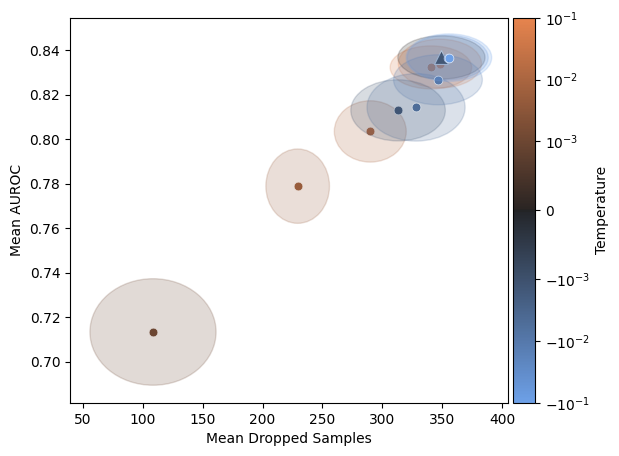

In [22]:
cmap = sns.color_palette("magma", as_cmap=True)
cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
norm = matplotlib.colors.SymLogNorm(linthresh=0.001, vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0

for key, dropped_value in dropped_samples[temperatures.astype(str)].items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.2,
                       color=color)
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")

In [23]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

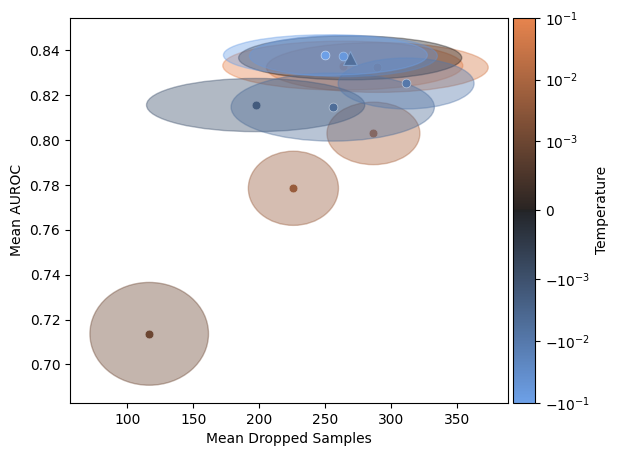

In [24]:
cmap = sns.color_palette("Spectral", as_cmap=True)
cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
norm = matplotlib.colors.SymLogNorm(linthresh=0.001, vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0

for key, dropped_value in dropped_samples[temperatures.astype(str)].items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.4,
                       color=color)
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")